In [1]:
import paddle
print(paddle.utils.run_check())

/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Running verify PaddlePaddle program ... 


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/pir/math_op_patch.py:241: UserWarning: Tensor do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(
I0316 02:35:46.326020 1807799 pir_interpreter.cc:1529] New Executor is Running ...
I0316 02:35:46.326313 1807799 pir_interpreter.cc:1552] pir interpreter is running by multi-thread mode ...


PaddlePaddle works well on 1 CPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
None


In [ ]:
from pathlib import Path
import subprocess
import sys

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
SCRIPT_PATH = BASE_DIR / "ppstructurev3_to_md.py"
OUT_DIR = BASE_DIR / "outputs_ppstructurev3_md"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay script: {SCRIPT_PATH}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc data: {DATA_DIR}")

pdf_files = sorted(DATA_DIR.rglob("*.pdf"))
print(f"Tim thay {len(pdf_files)} file PDF trong {DATA_DIR}")

for i, pdf_path in enumerate(pdf_files, 1):
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--input", str(pdf_path),
        "--output_dir", str(OUT_DIR),
        "--lang", "vi",
        "--device", "cpu",
        "--disable_mkldnn",
        "--page_header",
    ]

    print(f"[{i}/{len(pdf_files)}] Dang xu ly: {pdf_path.name}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode == 0:
        print("  OK")
    else:
        print("  FAIL")
        print(result.stderr[-1200:])

print(f"\nXong. File markdown o: {OUT_DIR}")

Tim thay 11 file PDF
[1/11] Dang xu ly: Public001.pdf
  OK  -> Public001_paddle_det_vietocr.txt
[2/11] Dang xu ly: Public002.pdf
  OK  -> Public002_paddle_det_vietocr.txt
[3/11] Dang xu ly: Public003.pdf
  OK  -> Public003_paddle_det_vietocr.txt
[4/11] Dang xu ly: Public004.pdf
  OK  -> Public004_paddle_det_vietocr.txt
[5/11] Dang xu ly: Public005.pdf
  OK  -> Public005_paddle_det_vietocr.txt
[6/11] Dang xu ly: Public253.pdf
  OK  -> Public253_paddle_det_vietocr.txt
[7/11] Dang xu ly: Public257.pdf


In [22]:
from pathlib import Path
import subprocess
import sys

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data_4"
SCRIPT_PATH = BASE_DIR / "ppstructurev3_to_md.py"
OUTPUT_DIR = BASE_DIR / "outputs_ppstructurev3_md"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay script: {SCRIPT_PATH}")
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc data: {DATA_DIR}")

pdf_files = sorted(DATA_DIR.rglob("*.pdf"))
print(f"Tim thay {len(pdf_files)} file PDF trong {DATA_DIR}")

success_files = []
failed_files = []

for index, pdf_path in enumerate(pdf_files, 1):
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--input", str(pdf_path),
        "--output_dir", str(OUTPUT_DIR),
        "--lang", "vi",
        "--device", "cpu",
        "--vietocr_device", "cpu",
        "--disable_mkldnn",
        "--page_header",
    ]

    print(f"[{index}/{len(pdf_files)}] Dang xu ly: {pdf_path}")
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode == 0:
        success_files.append(pdf_path)
        print("  OK")
    else:
        failed_files.append(pdf_path)
        print("  FAIL")
        if result.stderr:
            print(result.stderr[-1500:])
        elif result.stdout:
            print(result.stdout[-1500:])

print("\nTong ket")
print(f"- Thanh cong: {len(success_files)}")
print(f"- That bai: {len(failed_files)}")
print(f"- Thu muc output: {OUTPUT_DIR}")

if failed_files:
    print("\nDanh sach file loi:")
    for failed_path in failed_files:
        print(f"- {failed_path}")

Tim thay 1 file PDF trong /media/data3/users/huytq/huy/data_4
[1/1] Dang xu ly: /media/data3/users/huytq/huy/data_4/Public005.pdf
  OK

Tong ket
- Thanh cong: 1
- That bai: 0
- Thu muc output: /media/data3/users/huytq/huy/outputs_ppstructurev3_md


In [ ]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

import pypdfium2 as pdfium

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data_3" / "06_ Quy định ngoại ngữ từ K70_chính quy_final.pdf"
SCRIPT_PATH = BASE_DIR / "ppstructurev3_to_md.py"
PAGE_IMG_DIR = BASE_DIR / "debug"
PAGE_OUT_DIR = BASE_DIR / "outputs_ppstructurev3_md" / "Test_pages"

# Dat None de chay tat ca cac trang, hoac vi du [1, 2, 5]
PAGE_NUMBERS = None
SCALE = 2.0

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file PDF: {PDF_PATH}")
if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay script: {SCRIPT_PATH}")

if PAGE_IMG_DIR.exists():
    shutil.rmtree(PAGE_IMG_DIR)
PAGE_IMG_DIR.mkdir(parents=True, exist_ok=True)
PAGE_OUT_DIR.mkdir(parents=True, exist_ok=True)

pdf = pdfium.PdfDocument(str(PDF_PATH))
total_pages = len(pdf)
selected_pages = PAGE_NUMBERS or list(range(1, total_pages + 1))

print(f"Tong so trang: {total_pages}")
print(f"Se chay cac trang: {selected_pages}")

page_timings = []
failed_pages = []

for page_number in selected_pages:
    page_index = page_number - 1
    page = pdf[page_index]
    bitmap = page.render(scale=SCALE)
    pil_image = bitmap.to_pil()

    page_img_path = PAGE_IMG_DIR / f"Test_page_{page_number:03d}.png"
    pil_image.save(page_img_path)

    start_time = time.time()
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        "--input", str(page_img_path),
        "--output_dir", str(PAGE_OUT_DIR),
        "--lang", "vi",
        "--device", "cpu",
        "--vietocr_device", "cpu",
        "--disable_mkldnn",
        "--page_header",
    ]

    print(f"\nDang xu ly trang {page_number}: {page_img_path.name}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - start_time

    if result.returncode == 0:
        print(f"  OK - {elapsed:.1f}s")
        page_timings.append((page_number, elapsed))
    else:
        print(f"  FAIL - {elapsed:.1f}s")
        failed_pages.append(page_number)
        if result.stderr:
            print(result.stderr[-1500:])
        elif result.stdout:
            print(result.stdout[-1500:])

print("\nTong ket theo trang")
for page_number, elapsed in page_timings:
    print(f"- Trang {page_number}: {elapsed:.1f}s")

if failed_pages:
    print("\nTrang loi:")
    for page_number in failed_pages:
        print(f"- Trang {page_number}")

print(f"\nAnh tung trang nam o: {PAGE_IMG_DIR}")
print(f"Markdown tung trang nam o: {PAGE_OUT_DIR}")

In [2]:
from pathlib import Path
import subprocess
import sys
import time

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
MARKER_OUT_ROOT = BASE_DIR / "outputs"
MARKER_OUT_ROOT.mkdir(parents=True, exist_ok=True)

# Dat None de chay toan bo file.
# Vi du: "0-2" de test nhanh 3 trang dau moi file (Marker dung index trang bat dau tu 0).
PAGE_RANGE = None
TIMEOUT_SECONDS = 1800  # timeout cho moi file
MAX_FILES = None  # dat so nguyen de test nhanh, vd 3

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc: {DATA_DIR}")

pdf_files = sorted(DATA_DIR.rglob("*.pdf"))
if MAX_FILES is not None:
    pdf_files = pdf_files[:MAX_FILES]

if not pdf_files:
    raise FileNotFoundError(f"Khong tim thay file PDF trong: {DATA_DIR}")

# Dung marker_single trong dung env kernel. Neu chua co thi tu cai marker-pdf.
marker_single = Path(sys.executable).parent / "marker_single"
if not marker_single.exists():
    print("Khong tim thay marker_single, dang cai marker-pdf...")
    install_cmd = [sys.executable, "-m", "pip", "install", "marker-pdf"]
    install_result = subprocess.run(install_cmd, capture_output=True, text=True)
    if install_result.returncode != 0:
        print(install_result.stdout[-2000:])
        print(install_result.stderr[-2000:])
        raise RuntimeError("Cai marker-pdf that bai")
    marker_single = Path(sys.executable).parent / "marker_single"
    if not marker_single.exists():
        raise FileNotFoundError(f"Da cai marker-pdf nhung van khong tim thay marker_single: {marker_single}")

print(f"Tim thay {len(pdf_files)} file PDF trong {DATA_DIR}")

success_files = []
failed_files = []

for i, pdf_path in enumerate(pdf_files, 1):
    cmd = [
        str(marker_single),
        str(pdf_path),
        "--output_dir", str(MARKER_OUT_ROOT),
        "--output_format", "markdown",
        "--disable_multiprocessing",
    ]
    if PAGE_RANGE:
        cmd.extend(["--page_range", PAGE_RANGE])

    print(f"\n[{i}/{len(pdf_files)}] Dang xu ly: {pdf_path.name}")
    print("Lenh:", " ".join(cmd))

    start = time.time()
    try:
        # Khong capture_output de xem progress realtime
        completed = subprocess.run(cmd, text=True, timeout=TIMEOUT_SECONDS)
        return_code = completed.returncode
    except subprocess.TimeoutExpired:
        elapsed = time.time() - start
        print(f"  TIMEOUT sau {elapsed:.1f}s")
        failed_files.append((pdf_path, "timeout"))
        continue

    elapsed = time.time() - start
    print(f"  Thoi gian: {elapsed:.1f}s | Return code: {return_code}")

    base_name = pdf_path.stem
    md_path = MARKER_OUT_ROOT / base_name / f"{base_name}.md"

    if return_code == 0 and md_path.exists():
        print(f"  OK -> {md_path}")
        success_files.append((pdf_path, md_path))
    else:
        print(f"  FAIL -> khong thay markdown tai {md_path}")
        failed_files.append((pdf_path, "missing markdown"))

print("\nTong ket")
print(f"- Thanh cong: {len(success_files)}")
print(f"- That bai: {len(failed_files)}")

if failed_files:
    print("\nDanh sach loi:")
    for pdf_path, reason in failed_files:
        print(f"- {pdf_path} | {reason}")

Tim thay 8 file PDF trong /media/data3/users/huytq/huy/data

[1/8] Dang xu ly: Public001.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/data/Public001.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 3/3 [00:01<00:00,  1.67it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-17 21:05:58,779 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public001
2026-03-17 21:05:58,779 [INFO] marker: Total time: 176.42716717720032


  Thoi gian: 184.5s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public001/Public001.md

[2/8] Dang xu ly: Public002.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/data/Public002.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 3/3 [00:01<00:00,  1.60it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-17 21:08:40,783 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public002
2026-03-17 21:08:40,783 [INFO] marker: Total time: 154.90876364707947


  Thoi gian: 162.2s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public002/Public002.md

[3/8] Dang xu ly: Public003.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/data/Public003.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


...

  Thoi gian: 284.6s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public257/Public257.md

[7/8] Dang xu ly: Public282.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/data/Public282.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 2/2 [00:01<00:00,  1.98it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing tables: 100%|██████████| 1/1 [00:01<00:00,  1.23s/it]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-17 21:22:46,262 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public282
2026-03-17 21:22:46,262 [INFO] marker: Total time: 111.739590883255


  Thoi gian: 119.0s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public282/Public282.md

[8/8] Dang xu ly: Public283.pdf
Lenh: /media/data3/users/huytq/miniconda3/envs/huy/bin/marker_single /media/data3/users/huytq/huy/data/Public283.pdf --output_dir /media/data3/users/huytq/huy/outputs --output_format markdown --disable_multiprocessing


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
Running OCR Error Detection: 100%|██████████| 5/5 [00:02<00:00,  2.01it/s]
Detecting bboxes: 0it [00:00, ?it/s]
Recognizing tables: 100%|██████████| 2/2 [00:14<00:00,  7.28s/it]
Detecting bboxes: 0it [00:00, ?it/s]
2026-03-17 21:27:39,269 [INFO] marker: Saved markdown to /media/data3/users/huytq/huy/outputs/Public283
2026-03-17 21:27:39,270 [INFO] marker: Total time: 280.53707122802734


  Thoi gian: 293.0s | Return code: 0
  OK -> /media/data3/users/huytq/huy/outputs/Public283/Public283.md

Tong ket
- Thanh cong: 8
- That bai: 0


Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-DocLayout_plus-L`.


Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('latin_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/latin_PP-OCRv5_mobile_rec`.
Creating model: ('PP-Chart2Table', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table`.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Loading configuration file /media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table/config.json
Loading weights file /media/data3/users/huytq/.paddlex/official_models/PP-Chart2Table/model_state.pdparams
Loaded weigh

So block trang 1: 9
Thong ke label:
- text: 6
- table: 2
- paragraph_title: 1


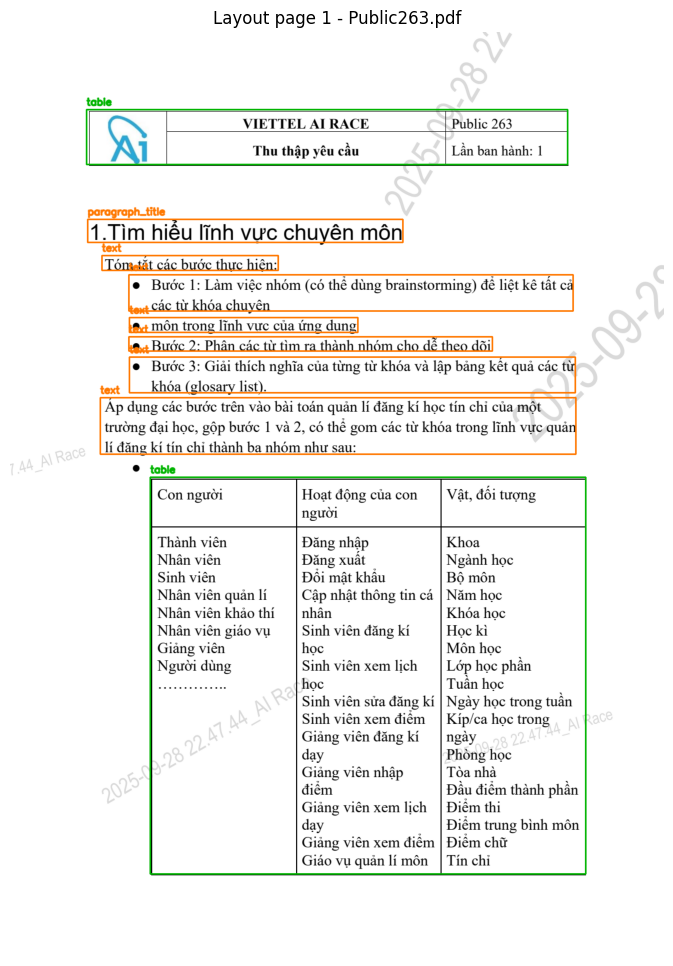

In [25]:
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import pypdfium2 as pdfium

from paddleocr import PPStructureV3

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data" / "Public263.pdf"  # doi file neu can

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file: {PDF_PATH}")

# 1) Render duy nhat trang dau tien cua PDF
pdf = pdfium.PdfDocument(str(PDF_PATH))
page0 = pdf[0]
bitmap = page0.render(scale=2.0)
pil_img = bitmap.to_pil()
page_img_bgr = cv2.cvtColor(cv2.cvtColor(__import__('numpy').array(pil_img), cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2RGB)
# page_img_bgr o dong tren thuc te dang RGB sau khi doi 2 lan, nen doi lai BGR de ve bang cv2
page_img_bgr = cv2.cvtColor(page_img_bgr, cv2.COLOR_RGB2BGR)

# 2) Chi chay layout parsing cho trang nay
layout_pipe = PPStructureV3(
    lang="vi",
    device="cpu",
    enable_mkldnn=False,
    enable_cinn=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    use_table_recognition=False,
    use_formula_recognition=False,
    use_seal_recognition=False,
    use_chart_recognition=False,
    use_region_detection=False,
)

res = layout_pipe.predict(page_img_bgr)
page_res = res[0]
blocks = page_res.get("parsing_res_list", [])

# 3) Ve bounding box len anh
canvas = page_img_bgr.copy()
label_counter = Counter()
for b in blocks:
    label = getattr(b, "label", "unknown")
    x1, y1, x2, y2 = map(int, getattr(b, "bbox", [0, 0, 0, 0]))
    label_counter[label] += 1

    color = (0, 180, 0) if label == "table" else (0, 120, 255)
    cv2.rectangle(canvas, (x1, y1), (x2, y2), color, 2)
    cv2.putText(
        canvas,
        label,
        (x1, max(y1 - 8, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2,
        cv2.LINE_AA,
    )

print(f"So block trang 1: {len(blocks)}")
print("Thong ke label:")
for label, count in label_counter.most_common():
    print(f"- {label}: {count}")

plt.figure(figsize=(18, 12))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title(f"Layout page 1 - {PDF_PATH.name}")
plt.axis("off")
plt.show()

In [26]:
from pathlib import Path
import cv2
import pypdfium2 as pdfium
import torch
from PIL import Image
from paddleocr import PPStructureV3, PaddleOCRVL

BASE_DIR = Path.cwd()
PDF_PATH = BASE_DIR / "data" / "Public263.pdf" 
MAX_BLOCKS = None  

if not PDF_PATH.exists():
    raise FileNotFoundError(f"Khong tim thay file: {PDF_PATH}")

# ====== Load VietOCR local ======
import sys
sys.path.insert(0, str(BASE_DIR / "vietocr"))
from tool.config import Cfg
from tool.translate import build_model, process_input, translate

vietocr_cfg = Cfg.load_config_from_file(
    str(BASE_DIR / "vietocr" / "config" / "vgg-seq2seq.yml"),
    base_file=str(BASE_DIR / "vietocr" / "config" / "base.yml"),
)
vietocr_cfg["device"] = "cpu"

vietocr_model, vietocr_vocab = build_model(vietocr_cfg)
ckpt = torch.load(str(BASE_DIR / "vietocr" / "weight" / "vgg_seq2seq.pth"), map_location="cpu")
if isinstance(ckpt, dict) and "state_dict" in ckpt:
    ckpt = ckpt["state_dict"]
if isinstance(ckpt, dict):
    ckpt = {(k[7:] if k.startswith("module.") else k): v for k, v in ckpt.items()}
vietocr_model.load_state_dict(ckpt, strict=False)
vietocr_model.eval()

# ====== Load pipeline ======
layout_pipe = PPStructureV3(
    lang="vi",
    device="cpu",
    enable_mkldnn=False,
    enable_cinn=False,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    use_table_recognition=False,
    use_formula_recognition=False,
    use_seal_recognition=False,
    use_chart_recognition=False,
    use_region_detection=False,
)

table_vl = PaddleOCRVL(
    device="cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_layout_detection=True,
    use_ocr_for_image_block=True,
    use_queues=False,
)

# ====== Render trang 1 ======
pdf = pdfium.PdfDocument(str(PDF_PATH))
page0 = pdf[0]
bitmap = page0.render(scale=2.0)
pil_img = bitmap.to_pil()
page_img_bgr = cv2.cvtColor(__import__('numpy').array(pil_img), cv2.COLOR_RGB2BGR)

# ====== Layout trang 1 ======
res = layout_pipe.predict(page_img_bgr)
blocks = res[0].get("parsing_res_list", [])
blocks = sorted(blocks, key=lambda b: (int(b.bbox[1]), int(b.bbox[0])))
if MAX_BLOCKS is not None:
    blocks = blocks[:MAX_BLOCKS]

print(f"So block duoc xu ly: {len(blocks)}")

# ====== OCR tung vung ======
for idx, b in enumerate(blocks, 1):
    label = getattr(b, "label", "unknown")
    x1, y1, x2, y2 = map(int, getattr(b, "bbox", [0, 0, 0, 0]))
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = max(x1 + 1, x2), max(y1 + 1, y2)

    crop = page_img_bgr[y1:y2, x1:x2]
    text_out = ""

    if label == "table":
        # Vung bang -> PaddleOCRVL
        import tempfile
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=True) as tmp:
            cv2.imwrite(tmp.name, crop)
            t_res = table_vl.predict(tmp.name)

        if t_res and t_res[0].get("parsing_res_list"):
            table_blocks = t_res[0]["parsing_res_list"]
            html_table = [str(tb.content) for tb in table_blocks if getattr(tb, "label", "") == "table"]
            text_out = "\n\n".join(html_table) if html_table else str(getattr(table_blocks[0], "content", ""))
        else:
            text_out = ""
    else:
        # Vung non-table -> VietOCR
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_pil = Image.fromarray(crop_rgb)
        tensor = process_input(
            crop_pil,
            vietocr_cfg["dataset"]["image_height"],
            vietocr_cfg["dataset"]["image_min_width"],
            vietocr_cfg["dataset"]["image_max_width"],
        ).to(vietocr_cfg["device"])

        pred_ids = translate(tensor, vietocr_model)
        if len(pred_ids) > 0:
            ids = pred_ids[0].tolist() if hasattr(pred_ids[0], "tolist") else list(pred_ids[0])
            text_out = vietocr_vocab.decode(ids)

    print(f"\n[{idx}] label={label} bbox={[x1, y1, x2, y2]}")
    print((text_out or "<empty>").strip()[:700])

/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Creating model: ('PP-DocLayout_plus-L', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/media/data3/users/huytq/.paddlex/official_models/PP-DocLayout_plus-L`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached file

So block duoc xu ly: 9


/media/data3/users/huytq/miniconda3/envs/huy/lib/python3.11/site-packages/paddle/tensor/creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(



[1] label=table bbox=[139, 141, 1015, 241]
<table><tr><td rowspan="2">$ \boxed{A_1} $</td><td>VIETTEL AI RACE</td><td>Public 263</td></tr><tr><td>Thu thập yêu cầu</td><td>Lần ban hành: 1</td></tr></table>

[2] label=paragraph_title bbox=[141, 341, 715, 383]
1 Tìm hiểu lĩnh vực chuyên môn

[3] label=text bbox=[167, 407, 488, 434]
Tóm tắt các bước thực hiện:

[4] label=text bbox=[216, 442, 1025, 508]
Bược 1 Làm việc nhóm (có thể dùng brainstorming) để liệt kê tất cản

[5] label=text bbox=[217, 520, 633, 547]
0ôm nông lĩnh vực của ứng dụng

[6] label=text bbox=[216, 555, 878, 581]
Bước 2: Phân các từ tìm ra thành nhóm cho dõi

[7] label=text bbox=[217, 592, 1029, 657]
Biện được 3: Giải thích nghĩa của từng từ khóa và lập bảng kết quả các trinh

[8] label=text bbox=[164, 666, 1030, 769]
Ap để đó thi thi trong tiến trong tiến thiến thiến thiến thi trong thi trong thu trong thi thi thi thi thi thi tháng tháng tháng

[9] label=table bbox=[255, 811, 1048, 1534]
<table><tr><td>Con người</td><t

In [ ]:
from pathlib import Path
from collections import Counter
import re

import pandas as pd

BASE_DIR = Path.cwd()
PRED_DIR = BASE_DIR / "outputs"              # doi thanh outputs_ppstructurev3_md neu can
GT_DIR = BASE_DIR / "grouth_truth"

# Khi True: giam anh huong cua markdown format (bullet, so thu tu, heading, table separator)
IGNORE_FORMAT_MARKERS = True

if not PRED_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc prediction: {PRED_DIR}")
if not GT_DIR.exists():
    raise FileNotFoundError(f"Khong tim thay thu muc ground truth: {GT_DIR}")


def normalize_text(s: str, ignore_format_markers: bool = True) -> str:
    s = s.replace("\r", "\n").lower()

    if ignore_format_markers:
        # Bo table separator markdown: |---|---|
        s = re.sub(r"(?m)^\s*\|?\s*[:\-]{2,}\s*(\|\s*[:\-]{2,}\s*)+\|?\s*$", " ", s)
        # Bo heading marker markdown
        s = re.sub(r"(?m)^\s*#{1,6}\s*", "", s)
        # Bo bullet marker dau dong: -, *, +, •
        s = re.sub(r"(?m)^\s*[-*+•]\s+", "", s)
        # Bo so thu tu dau dong: 1. / 1) / (1)
        s = re.sub(r"(?m)^\s*\(?\d+[\.)]\s+", "", s)

    # Chuan hoa khoang trang
    s = re.sub(r"\s+", " ", s)
    return s.strip()


def edit_distance(seq1, seq2) -> int:
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n

    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, m + 1):
            temp = dp[j]
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[j] = min(
                dp[j] + 1,      # delete
                dp[j - 1] + 1,  # insert
                prev + cost,    # substitute
            )
            prev = temp
    return dp[m]


def cer(pred: str, gt: str) -> float:
    gt_chars = list(gt)
    pred_chars = list(pred)
    if len(gt_chars) == 0:
        return 0.0 if len(pred_chars) == 0 else 1.0
    return edit_distance(pred_chars, gt_chars) / len(gt_chars)


def wer(pred: str, gt: str) -> float:
    gt_words = gt.split()
    pred_words = pred.split()
    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return edit_distance(pred_words, gt_words) / len(gt_words)


def token_prf1(pred: str, gt: str):
    pred_tokens = pred.split()
    gt_tokens = gt.split()

    pred_c = Counter(pred_tokens)
    gt_c = Counter(gt_tokens)

    overlap = sum((pred_c & gt_c).values())
    pred_total = sum(pred_c.values())
    gt_total = sum(gt_c.values())

    precision = overlap / pred_total if pred_total else 0.0
    recall = overlap / gt_total if gt_total else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return precision, recall, f1


# Index prediction file theo ten PublicXXX.md
pred_map = {}
for p in PRED_DIR.rglob("*.md"):
    pred_map[p.stem] = p

gt_files = sorted(GT_DIR.glob("*.md"))
if not gt_files:
    raise FileNotFoundError(f"Khong tim thay file .md trong {GT_DIR}")

rows = []
missing_pred = []

for gt_path in gt_files:
    key = gt_path.stem
    pred_path = pred_map.get(key)

    if pred_path is None:
        missing_pred.append(key)
        continue

    gt_text = normalize_text(
        gt_path.read_text(encoding="utf-8", errors="ignore"),
        ignore_format_markers=IGNORE_FORMAT_MARKERS,
    )
    pred_text = normalize_text(
        pred_path.read_text(encoding="utf-8", errors="ignore"),
        ignore_format_markers=IGNORE_FORMAT_MARKERS,
    )

    c = cer(pred_text, gt_text)
    w = wer(pred_text, gt_text)
    p, r, f1 = token_prf1(pred_text, gt_text)

    rows.append(
        {
            "file": key,
            "cer": c,
            "wer": w,
            "precision": p,
            "recall": r,
            "f1": f1,
            "pred_path": str(pred_path),
            "gt_path": str(gt_path),
        }
    )

if not rows:
    raise RuntimeError("Khong co file nao duoc so khop giua output va grouth_truth")

df = pd.DataFrame(rows).sort_values("file").reset_index(drop=True)

print("=== Tong ket ===")
print(f"So file ground-truth: {len(gt_files)}")
print(f"So file match de cham: {len(df)}")
print(f"So file thieu prediction: {len(missing_pred)}")
print(f"Ignore format markers: {IGNORE_FORMAT_MARKERS}")
if missing_pred:
    print("Thieu:", ", ".join(missing_pred))

print("\n=== Trung binh ===")
print(df[["cer", "wer", "precision", "recall", "f1"]].mean().to_string())

print("\n=== Chi tiet theo file ===")
display(df[["file", "cer", "wer", "precision", "recall", "f1"]])

print("\n=== Top file kem nhat theo CER ===")
display(df.sort_values("cer", ascending=False).head(5)[["file", "cer", "wer", "f1"]])

=== Tong ket ===
So file ground-truth: 8
So file match de cham: 8
So file thieu prediction: 0

=== Trung binh ===
cer          0.147131
wer          0.139127
precision    0.890645
recall       0.913685
f1           0.901892

=== Chi tiet theo file ===


,file,cer,wer,precision,recall,f1
0,Public001,0.043600,0.041621,0.961244,0.993788,0.977245
1,Public002,0.066472,0.068366,0.935241,0.970015,0.952311
2,Public003,0.057658,0.080359,0.926642,0.963331,0.944630
3,Public004,0.060776,0.054580,0.951272,0.990744,0.970607
4,Public005,0.023148,0.026099,0.975839,0.981128,0.978476
5,Public257,0.382175,0.329536,0.761084,0.736778,0.748734
6,Public282,0.138629,0.142238,0.871439,0.916076,0.893200
7,Public283,0.404588,0.370220,0.742397,0.757621,0.749931



=== Top file kem nhat theo CER ===


,file,cer,wer,f1
7,Public283,0.404588,0.370220,0.749931
5,Public257,0.382175,0.329536,0.748734
6,Public282,0.138629,0.142238,0.893200
1,Public002,0.066472,0.068366,0.952311
3,Public004,0.060776,0.054580,0.970607


\- TEDS (Tree Edit Distance for Structure): Dành riêng cho bảng biểu. Nó không chỉ xem chữ trong ô đúng không mà còn xem cấu trúc hàng/cột có bị lệch không <br>
\- TED (Text Edit Distance) sau khi Normalize: Họ dùng các regex để biến tất cả bullet point về cùng một loại, xóa khoảng trắng thừa, rồi mới đo CER/WER <br>
\- BLEU/ROUGE-L: Đo độ tương đồng về ngữ nghĩa. Nếu sai một từ nối nhưng công thức toán đúng, điểm vẫn sẽ cao <br>
\- LaTeX Similarity: Riêng với công thức toán, parse sang cây cú pháp để so sánh

In [5]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from collections import Counter
import math
import re

import pandas as pd


@dataclass
class EvaluationResult:
    cer: float
    wer: float
    bleu: float
    rouge_l: float
    table_f1: float
    formula_cer: float


class AdvancedOCREvaluator:
    """Evaluate OCR markdown output with text/table/formula aware metrics."""

    def __init__(self, lowercase: bool = True):
        self.lowercase = lowercase

    def evaluate_files(self, pred_path: str | Path, gt_path: str | Path) -> tuple[EvaluationResult, pd.DataFrame]:
        pred_text = Path(pred_path).read_text(encoding="utf-8", errors="ignore")
        gt_text = Path(gt_path).read_text(encoding="utf-8", errors="ignore")
        return self.evaluate_texts(pred_text, gt_text)

    def evaluate_texts(self, pred_text: str, gt_text: str) -> tuple[EvaluationResult, pd.DataFrame]:
        pred_norm = self._normalize_bullets(pred_text)
        gt_norm = self._normalize_bullets(gt_text)

        # Formula score
        pred_formulas = self._extract_formulas(pred_norm)
        gt_formulas = self._extract_formulas(gt_norm)
        formula_cer = self._formula_cer(pred_formulas, gt_formulas)

        # Table score (TEDS-like by cell matching)
        pred_tables = self._extract_tables(pred_norm)
        gt_tables = self._extract_tables(gt_norm)
        table_f1 = self._table_cell_f1(pred_tables, gt_tables)

        # Text-only content (remove table/formula regions)
        pred_text_only = self._extract_text_only(pred_norm)
        gt_text_only = self._extract_text_only(gt_norm)

        cer_val = self._cer(pred_text_only, gt_text_only)
        wer_val = self._wer(pred_text_only, gt_text_only)
        bleu_val = self._bleu(pred_text_only, gt_text_only)
        rouge_l_val = self._rouge_l(pred_text_only, gt_text_only)

        result = EvaluationResult(
            cer=cer_val,
            wer=wer_val,
            bleu=bleu_val,
            rouge_l=rouge_l_val,
            table_f1=table_f1,
            formula_cer=formula_cer,
        )

        summary = pd.DataFrame(
            [
                {
                    "CER": result.cer,
                    "WER": result.wer,
                    "BLEU": result.bleu,
                    "ROUGE-L": result.rouge_l,
                    "Table-F1": result.table_f1,
                    "Formula-CER": result.formula_cer,
                }
            ]
        )
        return result, summary
    
    def _normalize_basic(self, text: str) -> str:
        text = text.replace("\r", "\n")
        if self.lowercase:
            text = text.lower()
        return text

    def _normalize_bullets(self, text: str) -> str:
        """Normalize bullet markers (*, +, -) to a unified '-' marker at line start."""
        text = self._normalize_basic(text)
        text = re.sub(r"(?m)^\s*[*+]\s+", "- ", text)
        text = re.sub(r"(?m)^\s*-\s+", "- ", text)
        return text

    def _normalize_formula(self, s: str) -> str:
        s = s.strip()
        if self.lowercase:
            s = s.lower()
        s = re.sub(r"\s+", "", s)
        return s

    def _normalize_cell(self, s: str) -> str:
        s = self._normalize_basic(s)
        s = re.sub(r"\s+", " ", s).strip()
        return s

    def _extract_formulas(self, text: str) -> list[str]:
        text = self._normalize_basic(text)

        # Block formulas $$...$$
        block_matches = re.findall(r"\$\$(.+?)\$\$", text, flags=re.DOTALL)
        text_wo_blocks = re.sub(r"\$\$(.+?)\$\$", " ", text, flags=re.DOTALL)

        # Inline formulas $...$
        inline_matches = re.findall(r"\$(.+?)\$", text_wo_blocks, flags=re.DOTALL)

        formulas = [self._normalize_formula(x) for x in block_matches + inline_matches]
        return [f for f in formulas if f]

    def _extract_markdown_tables(self, text: str) -> list[list[list[str]]]:
        lines = text.splitlines()
        tables = []
        i = 0

        def is_pipe_line(line: str) -> bool:
            return "|" in line

        def is_separator_line(line: str) -> bool:
            # markdown separator: |---|:---:|---|
            return bool(re.fullmatch(r"\s*\|?\s*[:\-]+(?:\s*\|\s*[:\-]+)+\s*\|?\s*", line))

        while i < len(lines):
            if not is_pipe_line(lines[i]):
                i += 1
                continue

            # Collect contiguous pipe lines
            j = i
            chunk = []
            while j < len(lines) and is_pipe_line(lines[j]):
                chunk.append(lines[j])
                j += 1

            # Must contain at least one separator row to be a markdown table
            if any(is_separator_line(c) for c in chunk):
                table_rows = []
                for row in chunk:
                    if is_separator_line(row):
                        continue
                    parts = [p.strip() for p in row.strip().strip("|").split("|")]
                    if parts:
                        table_rows.append([self._normalize_cell(p) for p in parts])
                if table_rows:
                    tables.append(table_rows)

            i = j

        return tables

    def _extract_html_tables(self, text: str) -> list[list[list[str]]]:
        html_tables = re.findall(r"<table[\s\S]*?</table>", text, flags=re.IGNORECASE)
        out = []
        for t in html_tables:
            try:
                dfs = pd.read_html(t)
                for df in dfs:
                    arr = [
                        [self._normalize_cell(str(x)) for x in row]
                        for row in df.fillna("").astype(str).values.tolist()
                    ]
                    if arr:
                        out.append(arr)
            except Exception:
                continue
        return out

    def _extract_tables(self, text: str) -> list[list[list[str]]]:
        text = self._normalize_basic(text)
        md_tables = self._extract_markdown_tables(text)
        html_tables = self._extract_html_tables(text)
        return md_tables + html_tables

    def _extract_text_only(self, text: str) -> str:
        text = self._normalize_bullets(text)

        # Remove formulas
        text = re.sub(r"\$\$(.+?)\$\$", " ", text, flags=re.DOTALL)
        text = re.sub(r"\$(.+?)\$", " ", text, flags=re.DOTALL)

        # Remove html tables
        text = re.sub(r"<table[\s\S]*?</table>", " ", text, flags=re.IGNORECASE)

        # Remove markdown table rows (rough heuristic)
        text = re.sub(r"(?m)^\s*\|.*\|\s*$", " ", text)

        # Remove markdown table separator lines
        text = re.sub(r"(?m)^\s*\|?\s*[:\-]+(?:\s*\|\s*[:\-]+)+\s*\|?\s*$", " ", text)

        # Remove heading symbols but keep content
        text = re.sub(r"(?m)^\s*#{1,6}\s*", "", text)

        # Normalize spaces
        text = re.sub(r"\s+", " ", text).strip()
        return text

    # ---------------------------
    # Metrics
    # ---------------------------
    def _edit_distance(self, seq1, seq2) -> int:
        n, m = len(seq1), len(seq2)
        if n == 0:
            return m
        if m == 0:
            return n

        dp = list(range(m + 1))
        for i in range(1, n + 1):
            prev = dp[0]
            dp[0] = i
            for j in range(1, m + 1):
                temp = dp[j]
                cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
                dp[j] = min(
                    dp[j] + 1,      # delete
                    dp[j - 1] + 1,  # insert
                    prev + cost,    # substitute
                )
                prev = temp
        return dp[m]

    def _cer(self, pred: str, gt: str) -> float:
        gt_chars = list(gt)
        pred_chars = list(pred)
        if len(gt_chars) == 0:
            return 0.0 if len(pred_chars) == 0 else 1.0
        return self._edit_distance(pred_chars, gt_chars) / len(gt_chars)

    def _wer(self, pred: str, gt: str) -> float:
        gt_words = gt.split()
        pred_words = pred.split()
        if len(gt_words) == 0:
            return 0.0 if len(pred_words) == 0 else 1.0
        return self._edit_distance(pred_words, gt_words) / len(gt_words)

    def _bleu(self, pred: str, gt: str, max_n: int = 4, smooth: float = 1.0) -> float:
        ref = gt.split()
        hyp = pred.split()
        if len(hyp) == 0:
            return 0.0
        if len(ref) == 0:
            return 1.0 if len(hyp) == 0 else 0.0

        precisions = []
        for n in range(1, max_n + 1):
            ref_ngrams = Counter(tuple(ref[i:i + n]) for i in range(max(0, len(ref) - n + 1)))
            hyp_ngrams = Counter(tuple(hyp[i:i + n]) for i in range(max(0, len(hyp) - n + 1)))

            overlap = sum((hyp_ngrams & ref_ngrams).values())
            total = sum(hyp_ngrams.values())
            p_n = (overlap + smooth) / (total + smooth) if total > 0 else 0.0
            precisions.append(p_n)

        geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)

        ref_len = len(ref)
        hyp_len = len(hyp)
        if hyp_len > ref_len:
            bp = 1.0
        else:
            bp = math.exp(1 - ref_len / max(hyp_len, 1))

        return bp * geo_mean

    def _lcs_len(self, a: list[str], b: list[str]) -> int:
        n, m = len(a), len(b)
        dp = [0] * (m + 1)
        for i in range(1, n + 1):
            prev = 0
            for j in range(1, m + 1):
                temp = dp[j]
                if a[i - 1] == b[j - 1]:
                    dp[j] = prev + 1
                else:
                    dp[j] = max(dp[j], dp[j - 1])
                prev = temp
        return dp[m]

    def _rouge_l(self, pred: str, gt: str) -> float:
        ref = gt.split()
        hyp = pred.split()
        if len(ref) == 0 and len(hyp) == 0:
            return 1.0
        if len(ref) == 0 or len(hyp) == 0:
            return 0.0

        lcs = self._lcs_len(hyp, ref)
        prec = lcs / len(hyp)
        rec = lcs / len(ref)
        if prec + rec == 0:
            return 0.0
        return 2 * prec * rec / (prec + rec)

    def _table_cell_f1(self, pred_tables: list[list[list[str]]], gt_tables: list[list[list[str]]]) -> float:
        pred_cells = []
        gt_cells = []

        for t in pred_tables:
            for row in t:
                pred_cells.extend([c for c in row if c])
        for t in gt_tables:
            for row in t:
                gt_cells.extend([c for c in row if c])

        pred_c = Counter(pred_cells)
        gt_c = Counter(gt_cells)
        overlap = sum((pred_c & gt_c).values())

        pred_total = sum(pred_c.values())
        gt_total = sum(gt_c.values())

        if pred_total == 0 and gt_total == 0:
            return 1.0
        if pred_total == 0 or gt_total == 0:
            return 0.0

        precision = overlap / pred_total
        recall = overlap / gt_total
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)

    def _formula_cer(self, pred_formulas: list[str], gt_formulas: list[str]) -> float:
        # Match by order (simple and deterministic)
        n = min(len(pred_formulas), len(gt_formulas))
        if n == 0:
            return 0.0 if len(pred_formulas) == len(gt_formulas) else 1.0

        cer_vals = [self._cer(pred_formulas[i], gt_formulas[i]) for i in range(n)]

        # Penalize unmatched formulas
        unmatched = abs(len(pred_formulas) - len(gt_formulas))
        penalty = unmatched * 1.0

        return (sum(cer_vals) + penalty) / (n + unmatched)


# ---------------------------
# Example usage
# ---------------------------
# Dat truc tiep 2 file can cham
PRED_FILE = Path("/media/data3/users/huytq/huy/outputs/Public001/Public001.md")
GT_FILE = Path("/media/data3/users/huytq/huy/grouth_truth/Public001.md")

if not PRED_FILE.exists():
    raise FileNotFoundError(f"Khong tim thay prediction file: {PRED_FILE}")
if not GT_FILE.exists():
    raise FileNotFoundError(f"Khong tim thay ground-truth file: {GT_FILE}")

evaluator = AdvancedOCREvaluator(lowercase=True)
result, summary_df = evaluator.evaluate_files(PRED_FILE, GT_FILE)

print("=== Evaluation Summary ===")
print(f"CER         : {result.cer:.4f}")
print(f"WER         : {result.wer:.4f}")
print(f"BLEU        : {result.bleu:.4f}")
print(f"ROUGE-L     : {result.rouge_l:.4f}")
print(f"Table-F1    : {result.table_f1:.4f}")
print(f"Formula-CER : {result.formula_cer:.4f}")

print("\n=== DataFrame ===")
display(summary_df)

=== Evaluation Summary ===
CER         : 0.0422
WER         : 0.0379
BLEU        : 0.9535
ROUGE-L     : 0.9788
Table-F1    : 1.0000
Formula-CER : 0.0000

=== DataFrame ===


,CER,WER,BLEU,ROUGE-L,Table-F1,Formula-CER
0,0.042219,0.037856,0.953496,0.978769,1.0,0.0
